In [ ]:
import torch
import os
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
!pip install torchinfo

# Verify the GPU is working
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
from PIL import ImageFile, Image

# Fix for broken/corrupted images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Fix for massive/high-res images (Disables the Decompression Bomb warning)
Image.MAX_IMAGE_PIXELS = None

# Download the dataset (removed the deprecated --id flag for a cleaner output)
!gdown 1AdkW65yK0-WuekpLTixdxShGeQm6YiNk -O Carp_Dataset2.zip

# Unzip the downloaded file SILENTLY using both -o (overwrite) and -q (quiet)
!unzip -oq 'Carp_Dataset2.zip' -d '/content/'

print("Dataset successfully downloaded and extracted to Colab!")

Downloading...
From (original): https://drive.google.com/uc?id=1AdkW65yK0-WuekpLTixdxShGeQm6YiNk
From (redirected): https://drive.google.com/uc?id=1AdkW65yK0-WuekpLTixdxShGeQm6YiNk&confirm=t&uuid=f664ee4e-02da-4157-9792-7e9959aeb0ea
To: /content/Carp_Dataset2.zip
100% 2.36G/2.36G [00:22<00:00, 104MB/s] 
Dataset successfully downloaded and extracted to Colab!


Classes found: ['Catla', 'Common_Carp', 'Grass_Carp', 'Mrigal', 'Silver_Carp']


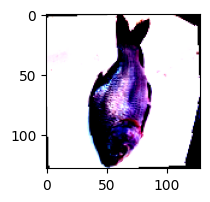

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = 128

# Set the directory to where we just unzipped the files
DATA_DIR = '/content/Carp_Dataset'

# 1. Define Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the dataset (PyTorch will naturally find 5 classes now)
full_dataset_train = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
full_dataset_test = datasets.ImageFolder(root=DATA_DIR, transform=test_transform)

# Verify classes
class_names = full_dataset_train.classes
print(f"Classes found: {class_names}")

plt.figure(figsize = (2,2))
plt.imshow(full_dataset_train[200][0].permute(1,2,0))


In [ ]:
# 3. Create Train/Val/Test Splits (70% Train, 15% Val, 15% Test)
dataset_size = len(full_dataset_train)
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_split = int(0.7 * dataset_size)
val_split = int(0.15 * dataset_size)

train_idx = indices[:train_split]
val_idx = indices[train_split : train_split + val_split]
test_idx = indices[train_split + val_split:]

train_dataset = Subset(full_dataset_train, train_idx)
val_dataset = Subset(full_dataset_test, val_idx)
test_dataset = Subset(full_dataset_test, test_idx)

# 4. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Total Images: {dataset_size}")
print(f"Training on {len(train_dataset)}, Validating on {len(val_dataset)}, Testing on {len(test_dataset)}.")

Total Images: 2164
Training on 1514, Validating on 324, Testing on 326.


In [ ]:
import torch.nn as nn
from torchinfo import summary

NUM_CLASSES = 5 # Katla, Common Carp, Grass Carp, Mrigal, Silver Carp

class CarpCNN(nn.Module):
    def __init__(self, num_classes=3, use_batchnorm=True, use_dropout=True):
        super(CarpCNN, self).__init__()

        # Block 1: Input (3, 128, 128) -> Output (32, 64, 64)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Input (32, 64, 64) -> Output (64, 32, 32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3: Input (64, 32, 32) -> Output (128, 16, 16)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else nn.Identity()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # Flattened size: 128 channels * 16 height * 16 width
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.drop = nn.Dropout(0.5) if use_dropout else nn.Identity()
        self.fc2 = nn.Linear(512, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass through convolutional blocks
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        # Flatten the tensor for the dense layers
        x = x.view(-1, 128 * 16 * 16)

        # Pass through fully connected blocks
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

# Instantiate the model and send it to the GPU
model = CarpCNN(num_classes=NUM_CLASSES, use_batchnorm=True, use_dropout=True).to(device)

# Print a beautiful summary of architecture
summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
CarpCNN                                  [32, 5]                   --
├─Conv2d: 1-1                            [32, 32, 128, 128]        896
├─BatchNorm2d: 1-2                       [32, 32, 128, 128]        64
├─ReLU: 1-3                              [32, 32, 128, 128]        --
├─MaxPool2d: 1-4                         [32, 32, 64, 64]          --
├─Conv2d: 1-5                            [32, 64, 64, 64]          18,496
├─BatchNorm2d: 1-6                       [32, 64, 64, 64]          128
├─ReLU: 1-7                              [32, 64, 64, 64]          --
├─MaxPool2d: 1-8                         [32, 64, 32, 32]          --
├─Conv2d: 1-9                            [32, 128, 32, 32]         73,856
├─BatchNorm2d: 1-10                      [32, 128, 32, 32]         256
├─ReLU: 1-11                             [32, 128, 32, 32]         --
├─MaxPool2d: 1-12                        [32, 128, 16, 16]         --
├─Li

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

EPOCHS = 15
LEARNING_RATE = 0.001

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler: Reduces learning rate by half if validation loss stops improving
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Dictionaries to track metrics for plotting later
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting Training Loop...")

for epoch in range(EPOCHS):
    # ==========================
    #        TRAINING
    # ==========================
    model.train() # Set model to training mode
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()      # Clear old gradients
        outputs = model(inputs)    # Forward pass
        loss = criterion(outputs, labels) # Calculate loss

        loss.backward()            # Backward pass (calculate gradients)
        optimizer.step()           # Update weights

        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ==========================
    #       VALIDATION
    # ==========================
    model.eval() # Set model to evaluation mode (turns off dropout)
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad(): # Don't calculate gradients during validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    # Step the scheduler
    scheduler.step(val_loss)

    # Save history for graphs
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] -> "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Save the trained model weights
torch.save(model.state_dict(), 'carp_cnn_weights.pth')
print("\nTraining Complete! Model weights saved as 'carp_cnn_weights.pth'")

Starting Training Loop...
Epoch [01/15] -> Train Loss: 5.8213, Train Acc: 0.3686 | Val Loss: 1.2022, Val Acc: 0.4753
Epoch [02/15] -> Train Loss: 1.1320, Train Acc: 0.5271 | Val Loss: 1.0298, Val Acc: 0.5525
Epoch [03/15] -> Train Loss: 1.0206, Train Acc: 0.5766 | Val Loss: 1.0054, Val Acc: 0.5802
Epoch [04/15] -> Train Loss: 0.9500, Train Acc: 0.6070 | Val Loss: 0.8168, Val Acc: 0.5988
Epoch [05/15] -> Train Loss: 0.9056, Train Acc: 0.6480 | Val Loss: 0.7724, Val Acc: 0.6975
Epoch [06/15] -> Train Loss: 0.8255, Train Acc: 0.6803 | Val Loss: 0.7097, Val Acc: 0.7377
Epoch [07/15] -> Train Loss: 0.8060, Train Acc: 0.6810 | Val Loss: 0.6909, Val Acc: 0.7315
Epoch [08/15] -> Train Loss: 0.7366, Train Acc: 0.7153 | Val Loss: 0.6458, Val Acc: 0.7500
Epoch [09/15] -> Train Loss: 0.7711, Train Acc: 0.7140 | Val Loss: 0.7336, Val Acc: 0.7685
Epoch [10/15] -> Train Loss: 0.7127, Train Acc: 0.7180 | Val Loss: 0.6512, Val Acc: 0.7346
Epoch [11/15] -> Train Loss: 0.7530, Train Acc: 0.7100 | Val Los

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# model is in evaluation mode
model.eval()

y_true = []
y_pred = []

print("Evaluating on the Test Set...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Print the comprehensive classification report
print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Evaluating on the Test Set...

--- Final Classification Report ---
              precision    recall  f1-score   support

       Catla       0.79      0.96      0.87        68
 Common_Carp       0.93      0.86      0.89        90
  Grass_Carp       0.55      0.77      0.65        53
      Mrigal       0.81      0.62      0.70        61
 Silver_Carp       0.93      0.69      0.79        54

    accuracy                           0.79       326
   macro avg       0.80      0.78      0.78       326
weighted avg       0.82      0.79      0.79       326



In [ ]:
'''Classification Report (Markdown)
Overall Accuracy (79%): Strong performance for a difficult 5-class problem.

Best Class: Common Carp (F1: 0.89). Its distinct dark, heavy scales make it the easiest for the CNN to identify.

Struggles: Grass Carp and Mrigal. The model frequently mixes them up, pulling their individual scores down.'''

'Classification Report (Markdown)\nOverall Accuracy (79%): Strong performance for a difficult 5-class problem.\n\nBest Class: Common Carp (F1: 0.89). Its distinct dark, heavy scales make it the easiest for the CNN to identify.\n\nStruggles: Grass Carp and Mrigal. The model frequently mixes them up, pulling their individual scores down.'

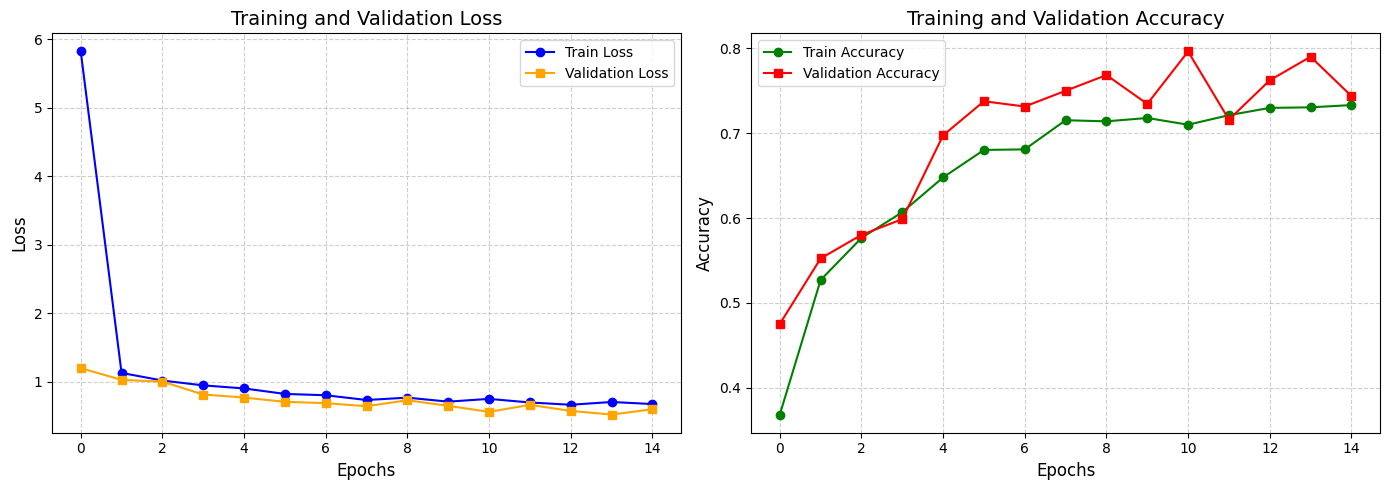

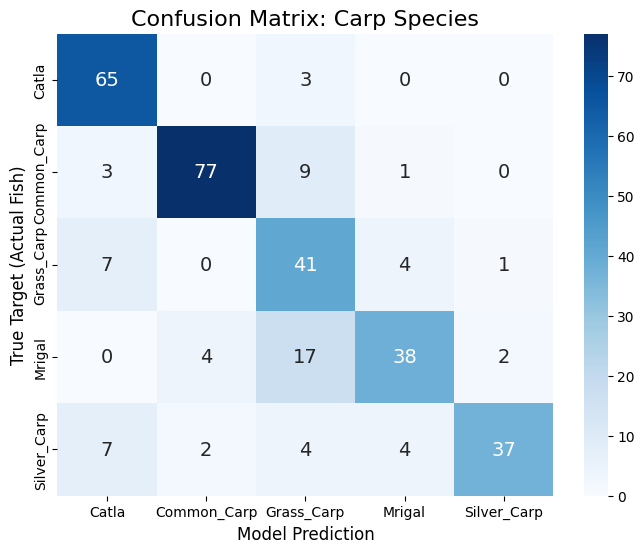

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for the curves
plt.figure(figsize=(14, 5))

# Plot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='orange', marker='s')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='green', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', color='red', marker='s')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Plot 3: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14}) # Make numbers larger
plt.title('Confusion Matrix: Carp Species', fontsize=16)
plt.ylabel('True Target (Actual Fish)', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.show()

In [ ]:
#Analysis:
'''Confusion Matrix (Markdown)
The Diagonal: The dark blue line down the middle proves the model is highly accurate for most classes.

The Main Error: The model misclassified 17 Mrigals as Grass Carps. Biologically, this makes sense: both are torpedo-shaped fish with similar silvery scales, confusing the model's visual filters.

Accuracy & Loss Curves (Markdown)
Accuracy Curve: The Training and Validation lines rise together, proving the model is genuinely learning the fish features and not just memorizing the pictures (no overfitting).

Loss Curve: The lines steadily drop, showing the model became more confident and made fewer severe mistakes over the 15 epochs. '''

"Confusion Matrix (Markdown)\nThe Diagonal: The dark blue line down the middle proves the model is highly accurate for most classes.\n\nThe Main Error: The model misclassified 17 Mrigals as Grass Carps. Biologically, this makes sense: both are torpedo-shaped fish with similar silvery scales, confusing the model's visual filters.\n\nAccuracy & Loss Curves (Markdown)\nAccuracy Curve: The Training and Validation lines rise together, proving the model is genuinely learning the fish features and not just memorizing the pictures (no overfitting).\n\nLoss Curve: The lines steadily drop, showing the model became more confident and made fewer severe mistakes over the 15 epochs. "

Hunting for misclassified fish...
Found 15 misclassified images to display.


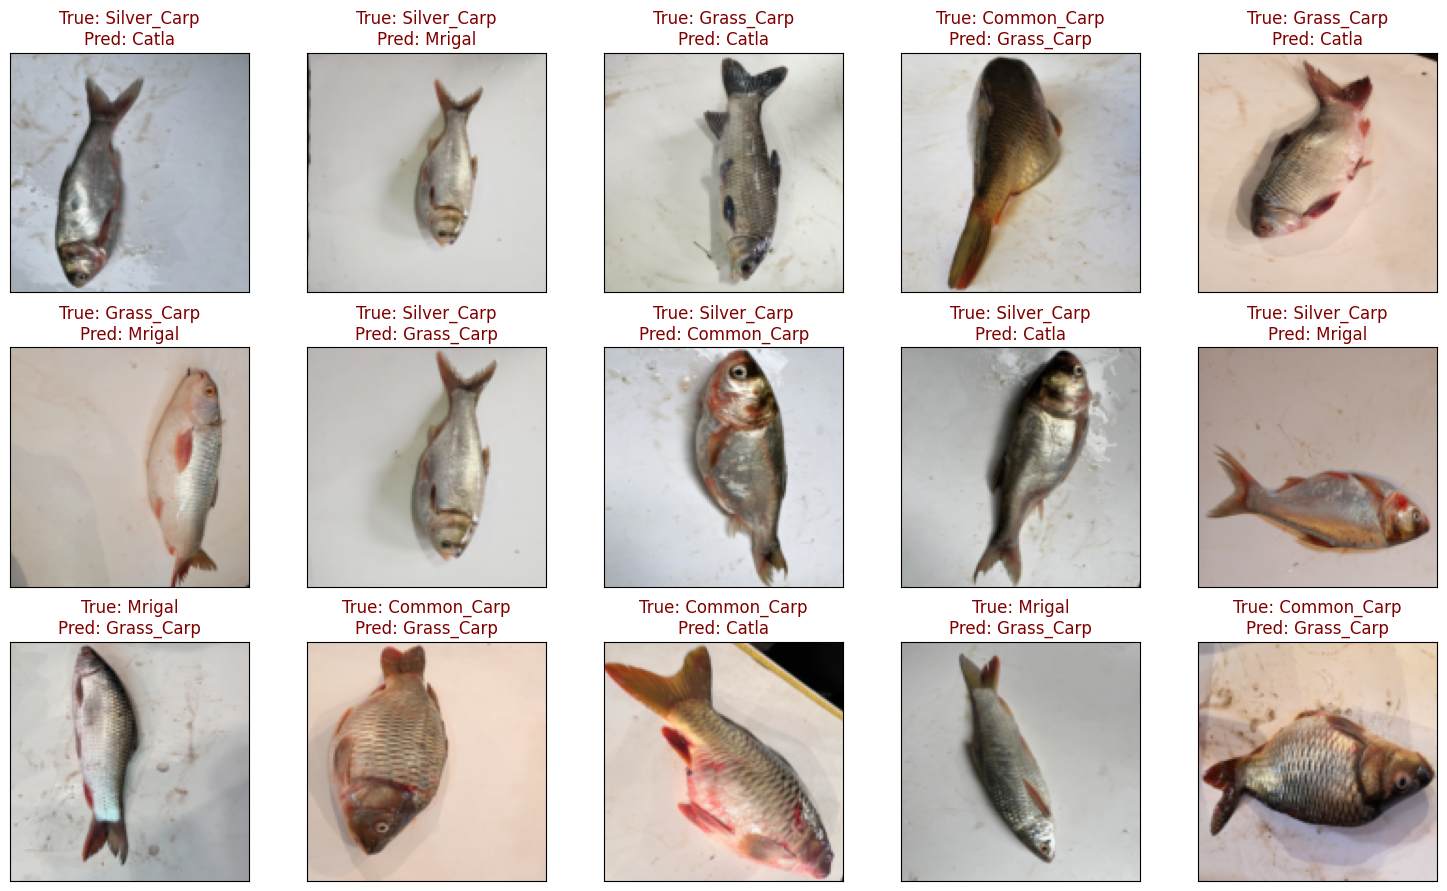

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Helper function to reverse the normalization so the image looks normal
def unnormalize_image(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0)) # Change shape from (C, H, W) to (H, W, C)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean   # Reverse the math
    img = np.clip(img, 0, 1) # Ensure pixel values are between 0 and 1
    return img

# 2. Collect misclassified images
model.eval()
misclassified_images = []
misclassified_true = []
misclassified_pred = []

print("Hunting for misclassified fish...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        # Find the indices in this batch where the prediction was wrong
        wrong_indices = (predicted != labels).nonzero(as_tuple=True)[0]

        for idx in wrong_indices:
            misclassified_images.append(inputs[idx].cpu())
            misclassified_true.append(labels[idx].item())
            misclassified_pred.append(predicted[idx].item())

            # Stop once we collect enough images for a nice grid (e.g., 15)
            if len(misclassified_images) >= 15:
                break
        if len(misclassified_images) >= 15:
            break

print(f"Found {len(misclassified_images)} misclassified images to display.")

# 3. Plot the grid
if len(misclassified_images) > 0:
    # Calculate grid size (max 3 rows, 5 columns)
    num_images = len(misclassified_images)
    cols = 5
    rows = (num_images + cols - 1) // cols

    fig = plt.figure(figsize=(15, 3 * rows))

    for i in range(num_images):
        ax = fig.add_subplot(rows, cols, i+1, xticks=[], yticks=[])

        # Display the un-normalized image
        img_to_show = unnormalize_image(misclassified_images[i])
        ax.imshow(img_to_show)

        # Add the True/Pred labels as the title
        true_name = class_names[misclassified_true[i]]
        pred_name = class_names[misclassified_pred[i]]

        # Color the title red to indicate it's an error
        ax.set_title(f"True: {true_name}\nPred: {pred_name}", color="maroon")

    plt.tight_layout()
    plt.show()
else:
    print("Your model is perfect on the test set! No misclassifications to show.")